<left>
<table style="margin-top:0px; margin-left:0px;">
<tr>
  <td><img src="https://raw.githubusercontent.com/worm-portal/WORM-Figures/master/style/worm.png" alt="WORM" title="WORM" width=50/></td>
  <td><h1 style=font-size:30px>Introduction to Custom Databases:<br>Rocks Under Pressure!</h1><br />
</tr>
</table>
</left>

<img src="https://upload.wikimedia.org/wikipedia/commons/0/00/HuangShan.JPG" alt="Granite" title="'A granite peak at Huangshan, China'" width=500/>

A granite peak at Huangshan, China (Arne Hückelheim)

It's typical to have a rock sample, but unusual to have a sample of water that was in the ground when the mineral assemblage was formed.

What kind of temperature and pressure did the rock form at? What was dissolved in the fluid?

<img src="https://lede-admin.nautil.us/wp-content/uploads/sites/70/6392_3001ef257407d5a371a96dcd947c7d93.jpg?w=2560" alt="Granite" title="'Granite meets water in the Sierra Mountains'" width=500/>

Granite meets water in the Sierra Mountains (Julia Rosen)

The fluid is long gone, but we can use thermodynamic calculations to estimate it. It's also possible to explore the effects of temperature and pressure on the chemical activities of dissolved species.

### Buffer solutes with minerals

How can we estimate the geochemistry of a ~0.5 molal NaCl fluid in equilibrium with granite?

First of all, [what's in granite?](https://nature.berkeley.edu/classes/eps2/wisc/granite.html)
- 80% of the rock:
    - [quartz](https://en.wikipedia.org/wiki/Quartz) (10-50%)
    - potassium and plagioclase [feldspar](https://en.wikipedia.org/wiki/Feldspar) (like albite)
- other common minerals:
    - [mica](https://en.wikipedia.org/wiki/Mica) ([muscovite](https://en.wikipedia.org/wiki/Muscovite) and [biotite](https://en.wikipedia.org/wiki/Biotite))
    - [hornblende](https://en.wikipedia.org/wiki/Hornblende) ([amphibole](https://en.wikipedia.org/wiki/Amphibole))
    
Based on the elements in these minerals, the solution in our aqueous speciation calculation should include basis species to constrain Si, K, Na, Al, Fe, Mg (and others, if the granite has been hydrothermally altered with other minerals).

Open the `granite0.csv` input file. It includes some initial constraints that represent a starting guess, but none of the basis species are in equilibrium with minerals yet.

The basis species constraining Si is aqueous SiO2. The initial guess for the concentration of dissolved silica is $3\times10^{-3}$ molal.

We can run the sample as-is with:

In [1]:
# get the notebook ready
import aqequil
ae = aqequil.AqEquil()

Loading Water-Organic-Rock-Microbe (WORM) thermodynamic databases...
wrm_data_latest.csv is now set as the active thermodynamic database.
Element database elements.csv is active.
Solid solution database solid_solutions.csv is active.
LogK database wrm_data_logk.csv is active.
LogK_S database wrm_data_logk_s.csv is active.
Loading thermodynamic database into pyCHNOSZ...


In [2]:
# speciate the sample
speciation_0 = ae.speciate(
    input_filename = "granite0.csv", # name of csv with fluid sample data
    exclude = ["Year", "Area"], # metadata columns excluded from calculation
    report_filename = 'granite0report.csv', # write a csv of results with this name
    redox_flag = "logfO2", # desired option for setting redox state, logfO2 by default
    )

Getting wrm_data_latest.csv ready. This will take a moment...
Using wrm_data_latest.csv to speciate granite0
Finished!


Once the speciation is finished, results can be viewed in the `granite0report.csv` file, or with the lookup function:

In [3]:
speciation_0.lookup(["Temperature", "logfO2", "Pressure", "pH"])

Sample,Temperature,logfO2,Pressure,pH
,degC,logfO2,bar,pH
Sample,,,,
granite0,200,-40,1000.0,6.0


In [4]:
speciation_0.lookup(["SiO2_(input)", "HSiO3-", "NaHSiO3", "SiO2"])

Sample,SiO2_(input),HSiO3-,NaHSiO3,SiO2
,Molality,log_activity,log_activity,log_activity
Sample,,,,
granite0,3.00E-03,-4.9775,-4.7666,-2.5278


To allow quartz to buffer the concentration of SiO2, change the column subheader to `Hetero. equil.` (short for heterogeneous equilibrium). Then replace the $3\times10^{-3}$ value with the word `quartz`.

This has been done in `granite1.csv`. Let's see what happens when we allow quartz to buffer SiO2:

In [5]:
# speciate the sample
speciation_1 = ae.speciate(
    input_filename = "granite1.csv", # name of csv with fluid sample data
    exclude = ["Year", "Area"], # metadata columns excluded from calculation
    report_filename = 'granite1report.csv', # write a csv of results with this name
    redox_flag = "logfO2", # desired option for setting redox state, logfO2 by default
    )

Getting wrm_data_latest.csv ready. This will take a moment...
Using wrm_data_latest.csv to speciate granite1
Finished!


In [6]:
speciation_1.lookup(["SiO2_(input)", "HSiO3-", "NaHSiO3", "SiO2"])

Sample,SiO2_(input),HSiO3-,NaHSiO3,SiO2
,Hetero. equil.,log_activity,log_activity,log_activity
Sample,,,,
granite1,quartz,-4.7561,-4.5452,-2.3064


The activities of dissolved silica species have shifted since our initial guess of $3\times10^{-3}$ molal SiO2!

In the breakout session, look for ways to constrain more elements with minerals in granite. You might need to constrain multiple elements at once for an aqueous speciation calculation to complete.

### Exclude aqueous organics

The WORM thermodynamic database contains aqueous organic molecules. Notice that if we provide a basis species for carbon (HCO<sub>3</sub><sup>-</sup>) in granite6.csv, some of it speciates into aqueous organic molecules like 1-octyne, nonanol, and n-pentylbenzene. What if we don't want to include these in the calculation?

In [7]:
# speciate the sample
speciation_6 = ae.speciate(
    input_filename = "granite6.csv", # name of csv with fluid sample data
    exclude = ["Year", "Area"], # metadata columns excluded from calculation
    report_filename = 'granite6report.csv', # write a csv of results with this name
    redox_flag = "O2(g)", # desired option for setting redox state
    )

Getting wrm_data_latest.csv ready. This will take a moment...
Using wrm_data_latest.csv to speciate granite6
Finished!


In [8]:
speciation_6.sample_data["granite6"]["aq_distribution"]

,molality,log_molality,log_gamma,log_activity
species,,,,
Cl-,4.389800e-01,-0.357600,-0.2440,-0.601500
Na+,3.602900e-01,-0.443400,-0.2445,-0.687900
NaCl,3.967400e-02,-1.401500,0.0000,-1.401500
Ca+2,2.895200e-02,-1.538300,-0.8118,-2.350100
CaCl+,1.980200e-02,-1.703300,-0.2445,-1.947800
...,...,...,...,...
H-sebacate,1.140200e-91,-90.943000,-0.2085,-91.151500
sebacic-acid,4.590700e-93,-92.338100,0.0000,-92.338100
n-pentylbenzene,6.029000e-97,-96.219800,0.0000,-96.219800


*Above: aqueous organics show up in the 'granite6' sample*

Organic molecules can be excluded from the calculation using the `exclude_organics` parameter. This usually speeds up the calculation significantly.

In [9]:
# exclude aqueous organics
ae = aqequil.AqEquil(exclude_organics=True)

# speciate the sample
speciation_6_no_aq_org = ae.speciate(
    input_filename = "granite6.csv", # name of csv with fluid sample data
    exclude = ["Year", "Area"], # metadata columns excluded from calculation
    report_filename = 'granite6report.csv', # write a csv of results with this name
    redox_flag = "O2(g)", # desired option for setting redox state, logfO2 by default
    )

Loading Water-Organic-Rock-Microbe (WORM) thermodynamic databases...
Excluding ['organic_aq', 'organic_cr'] from column 'category_1'in wrm_data_latest.csv
wrm_data_latest.csv is now set as the active thermodynamic database.
Element database elements.csv is active.
Solid solution database solid_solutions.csv is active.
LogK database wrm_data_logk.csv is active.
Excluding ['organic_aq', 'organic_cr'] from column 'category_1'in wrm_data_logk.csv
LogK_S database wrm_data_logk_s.csv is active.
Excluding ['organic_aq', 'organic_cr'] from column 'category_1'in wrm_data_logk_s.csv
Loading thermodynamic database into pyCHNOSZ...
Getting wrm_data_latest.csv ready. This will take a moment...
Using wrm_data_latest.csv to speciate granite6
Finished!


The curly brackets mean you can specify a few different parameters in `db_args`, including `exclude_category`.
Note that aqueous organics are no longer present after excluding them:

In [10]:
speciation_6_no_aq_org.sample_data["granite6"]["aq_distribution"]

,molality,log_molality,log_gamma,log_activity
species,,,,
Cl-,4.389800e-01,-0.357600,-0.2440,-0.601500
Na+,3.602900e-01,-0.443400,-0.2445,-0.687900
NaCl,3.967400e-02,-1.401500,0.0000,-1.401500
Ca+2,2.895200e-02,-1.538300,-0.8118,-2.350100
CaCl+,1.980200e-02,-1.703300,-0.2445,-1.947800
...,...,...,...,...
O2,1.658000e-44,-43.780400,0.0681,-43.712300
ClO2-,4.982000e-61,-60.302600,-0.2085,-60.511100
HClO2,4.611100e-64,-63.336200,0.0000,-63.336200


Other parameters can be defined in `db_args`. These will be covered in other WORM tutorial notebooks.

### Check solid solutions

If you have included solid solutions in your sample, you can visualize them with `plot_solid_solutions`.

The upper plot displays mole fractions of the solid solution endmembers. The lower plot depicts whether the solid solution is supersaturated (blue) or undersaturated (orange) with respect to the fluid.

Switching from 'WORM' colormap to 'viridis' because there are 27 variables to plot.


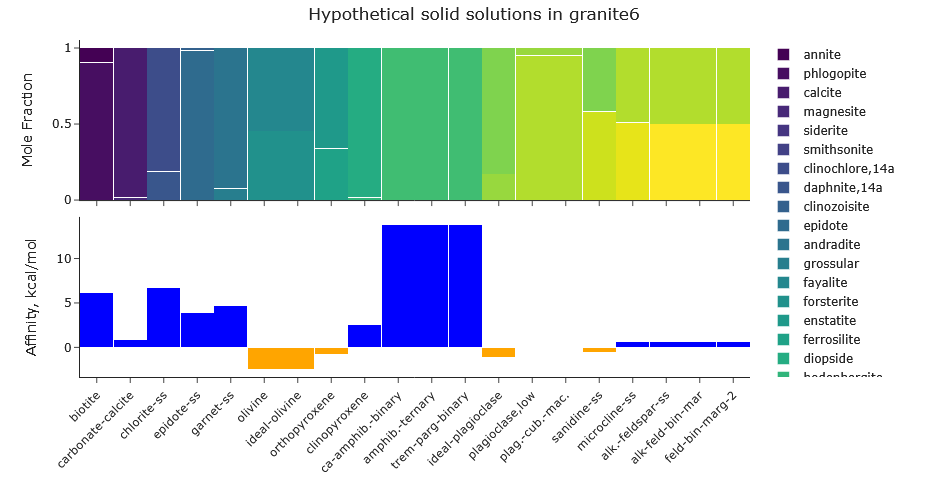

In [11]:
speciation_6_no_aq_org.plot_solid_solutions("granite6")

### Exercise: Geochemical Sudoku!
Open 2-Exercise.ipynb to begin.